# FORS-EMG Improved Baseline

Group 11 — Improved baseline pipeline based on:
- Rumman et al. (2024): dataset paper, FS=985 Hz, bandpass 20–450 Hz
- Aarotale & Rattani (2024): TSD features + RF → 94.95%
- Çelik & Can (2026): preprocessing pipeline, windowing params

**Target:** Beat existing baseline (MLP 55.02%) and approach 94.95% with TSD+RF

## Phase 1 — Data loading & metadata

In [1]:
import os
import re
import numpy as np
import pandas as pd
import scipy.io as sio
from pathlib import Path

# Dataset path
DATA_DIR = r"C:\Users\Asus\Documents\Group11_Fors_EMG_Project\Fors_EMG_Dataset"

records = []

for root, dirs, files in os.walk(DATA_DIR):
    for f in files:

        if not f.lower().endswith('.mat'):
            continue

        fpath = os.path.join(root, f)

        parts = Path(fpath).parts

        subject = parts[-3]
        orientation = parts[-2]

        name = Path(f).stem

        m = re.match(r'(.+)-(\d+)$', name)

        gesture = m.group(1) if m else name
        trial = int(m.group(2)) if m else 0

        records.append({
            'File': fpath,
            'Subject': subject,
            'Orientation': orientation,
            'Gesture': gesture,
            'Trial': trial
        })

metadata = pd.DataFrame(records)

print('Total files  :', len(metadata))
print('Subjects     :', metadata.Subject.nunique())
print('Orientations :', sorted(metadata.Orientation.unique()))
print('Gestures     :', sorted(metadata.Gesture.unique()))

metadata.head()

Total files  : 3420
Subjects     : 19
Orientations : ['Pronation', 'Rest', 'Supination', 'pronation', 'rest', 'supination']
Gestures     : ['Hand_Close', 'Hand_Open', 'Index', 'Index_Little', 'Peace', 'Radial_Deviation', 'Right_Angle', 'Thumb_Little', 'Thumb_UP', 'Ulner_Deviation', 'Wrist_Extension', 'Wrist_Flexion']


,File,Subject,Orientation,Gesture,Trial
0,C:\Users\Asus\Documents\Group11_Fors_EMG_Proje...,Subject1,pronation,Hand_Close,1
1,C:\Users\Asus\Documents\Group11_Fors_EMG_Proje...,Subject1,pronation,Hand_Close,2
2,C:\Users\Asus\Documents\Group11_Fors_EMG_Proje...,Subject1,pronation,Hand_Close,3
3,C:\Users\Asus\Documents\Group11_Fors_EMG_Proje...,Subject1,pronation,Hand_Close,4
4,C:\Users\Asus\Documents\Group11_Fors_EMG_Proje...,Subject1,pronation,Hand_Close,5


## Phase 2 — Subject-wise split

Same split as existing baseline: 15 train / 2 val / 2 test.  
This mirrors the subject-wise protocol used by Çelik & Can (2026).

In [2]:
TRAIN_SUBJECTS = [
    'Subject1','Subject2','Subject3','Subject4','Subject5',
    'Subject6','Subject7','Subject8','Subject9','Subject10',
    'Subject11','Subject12','Subject13','Subject14','Subject15'
]
VAL_SUBJECTS  = ['Subject16','Subject17']
TEST_SUBJECTS = ['Subject18','Subject19']

train_meta = metadata[metadata.Subject.isin(TRAIN_SUBJECTS)].reset_index(drop=True)
val_meta   = metadata[metadata.Subject.isin(VAL_SUBJECTS)].reset_index(drop=True)
test_meta  = metadata[metadata.Subject.isin(TEST_SUBJECTS)].reset_index(drop=True)

# Leakage check
assert set(TRAIN_SUBJECTS).isdisjoint(VAL_SUBJECTS)
assert set(TRAIN_SUBJECTS).isdisjoint(TEST_SUBJECTS)
assert set(VAL_SUBJECTS).isdisjoint(TEST_SUBJECTS)
print('Subject-wise split: PASSED')
print(f'Train: {len(train_meta)} | Val: {len(val_meta)} | Test: {len(test_meta)}')

Subject-wise split: PASSED
Train: 2700 | Val: 360 | Test: 360


## Phase 3 — Preprocessing

Per **Çelik & Can (2026)** and **Rumman et al. (2024)**:
- 4th-order Butterworth bandpass **20–450 Hz** (forward-backward `filtfilt` — zero phase)
- Notch filter **50 Hz** (powerline interference)
- FS = **985 Hz** (confirmed from dataset paper)

No preprocessing existed in the previous baseline.

In [3]:
from scipy.signal import butter, filtfilt, iirnotch

FS = 985  # Hz — confirmed from Rumman et al. (2024)

def make_bandpass(lowcut=20, highcut=450, fs=FS, order=4):
    nyq = fs / 2
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return b, a

def make_notch(freq=50, q=30, fs=FS):
    """Q=30 gives a narrow notch — standard for powerline removal."""
    b, a = iirnotch(freq / (fs/2), q)
    return b, a

BP_B, BP_A = make_bandpass()
NT_B, NT_A = make_notch()

def preprocess_signal(signal):
    """Apply bandpass then notch to each channel. signal shape: (8, 8000)."""
    out = np.zeros_like(signal, dtype=np.float64)
    for ch in range(signal.shape[0]):
        x = filtfilt(BP_B, BP_A, signal[ch].astype(np.float64))
        x = filtfilt(NT_B, NT_A, x)
        out[ch] = x
    return out

# Quick sanity check on one file
sample_file = train_meta.iloc[0]['File']
raw  = sio.loadmat(sample_file)['value']          # (8, 8000)
proc = preprocess_signal(raw)
print('Raw  shape:', raw.shape,  '| mean abs:', round(np.mean(np.abs(raw)), 5))
print('Proc shape:', proc.shape, '| mean abs:', round(np.mean(np.abs(proc)), 5))
print('Preprocessing functions ready.')

Raw  shape: (8, 8000) | mean abs: 0.05396
Proc shape: (8, 8000) | mean abs: 0.05236
Preprocessing functions ready.


## Phase 4 — Windowing

Per **Çelik & Can (2026)**:
- Window size: **492 samples** (~0.5 s at 985 Hz)
- Stride: **246 samples** (50% overlap)
- Each trial → **31 windows**

In [4]:
WINDOW_SIZE = 492
STRIDE      = 246   # 50% overlap

def make_windows(signal, window_size=WINDOW_SIZE, stride=STRIDE):
    """Returns array of shape (n_windows, 8, window_size)."""
    n_ch, n_samples = signal.shape
    starts = range(0, n_samples - window_size + 1, stride)
    return np.stack([signal[:, s:s+window_size] for s in starts])

# Verify
windows = make_windows(proc)
print(f'Signal shape   : {proc.shape}')
print(f'Windows shape  : {windows.shape}  →  {windows.shape[0]} windows per trial')
print(f'Window duration: {WINDOW_SIZE/FS*1000:.0f} ms')
print(f'Overlap        : 50%')

Signal shape   : (8, 8000)
Windows shape  : (31, 8, 492)  →  31 windows per trial
Window duration: 499 ms
Overlap        : 50%


## Phase 5 — TSD feature extraction

Per **Aarotale & Rattani (2024)** — the feature set that gave **94.95% with RF** on FORS-EMG.

For each window, for each channel, compute:
- M0 (RMS zero-order moment), M2, M4
- Sparseness, IRF (irregularity factor), COV, TKEO

Then pairwise **between-channel** features for all 28 channel pairs (8 choose 2).

In [5]:
from itertools import combinations

def _moments(x):
    """Root squared moments (M0, M2, M4) from a 1-D array."""
    N  = len(x)
    dx = np.diff(x, n=1, prepend=x[0])
    d2x= np.diff(x, n=2, prepend=[x[0], x[0]])
    m0 = np.sqrt(np.mean(x**2))          # RMS
    m2 = np.sqrt(np.mean(dx**2))
    m4 = np.sqrt(np.mean(d2x**2))
    return m0, m2, m4

def _tsd_single(x):
    """7 TSD features from a single channel array x."""
    m0, m2, m4 = _moments(x)
    eps = 1e-10

    # Sparseness
    sparseness = (np.sqrt(m0) / (m0 - m2 + eps)) * (np.sqrt(m0) - m4 + eps) \
                 if (m0 - m2 + eps) != 0 else 0.0
    sparseness = np.log(np.abs(sparseness) + eps)

    # IRF — irregularity factor
    irf = np.log(m2 / (np.sqrt(m0 * m4) + eps) + eps)

    # COV — coefficient of variation
    mu  = np.mean(x)
    std = np.std(x)
    cov = np.log(std / (np.abs(mu) + eps) + eps)

    # TKEO — Teager-Kaiser energy operator
    tkeo = x[1:-1]**2 - x[:-2] * x[2:]
    tkeo_feat = np.log(np.sum(np.abs(tkeo)) + eps)

    return np.array([m0, m2, m4, sparseness, irf, cov, tkeo_feat])

N_CH   = 8
PAIRS  = list(combinations(range(N_CH), 2))  # 28 pairs

def extract_tsd(window):
    """
    window: (8, 492)
    Returns 1-D feature vector.
    Within-channel: 8 ch × 7 features = 56
    Between-channel: 28 pairs × 7 features = 196
    Total: 252 features
    """
    feats = []
    # Within-channel
    for ch in range(N_CH):
        feats.append(_tsd_single(window[ch]))
    # Between-channel (pairwise difference)
    for i, j in PAIRS:
        diff = window[i] - window[j]
        feats.append(_tsd_single(diff))
    return np.concatenate(feats).astype(np.float32)

# Verify feature count
test_feat = extract_tsd(windows[0])
print(f'Features per window: {len(test_feat)}')
print(f'  Within-channel : 8 × 7 = {8*7}')
print(f'  Between-channel: 28 × 7 = {28*7}')
print(f'  Total          : {8*7 + 28*7}')

Features per window: 252
  Within-channel : 8 × 7 = 56
  Between-channel: 28 × 7 = 196
  Total          : 252


In [6]:
from tqdm.auto import tqdm

def process_split_tsd(df, desc='Processing'):
    """Load → preprocess → window → TSD features for an entire split."""
    X_list, y_list = [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        raw    = sio.loadmat(row['File'])['value']   # (8, 8000)
        proc   = preprocess_signal(raw)
        wins   = make_windows(proc)                  # (31, 8, 492)
        for w in wins:
            X_list.append(extract_tsd(w))
            y_list.append(row['Gesture'])
    return np.array(X_list, dtype=np.float32), np.array(y_list)

print('Extracting TSD features for all splits...')
X_train, y_train = process_split_tsd(train_meta, 'Train')
X_val,   y_val   = process_split_tsd(val_meta,   'Val  ')
X_test,  y_test  = process_split_tsd(test_meta,  'Test ')

print(f'\nX_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_val  : {X_val.shape}  y_val  : {y_val.shape}')
print(f'X_test : {X_test.shape}  y_test : {y_test.shape}')

Extracting TSD features for all splits...


Train:   0%|          | 0/2700 [00:00<?, ?it/s]

Val  :   0%|          | 0/360 [00:00<?, ?it/s]

Test :   0%|          | 0/360 [00:00<?, ?it/s]


X_train: (83700, 252)  y_train: (83700,)
X_val  : (11160, 252)  y_val  : (11160,)
X_test : (11160, 252)  y_test : (11160,)


## Phase 6 — Normalisation

StandardScaler fit on training data only — no leakage.  
Infinite / NaN values from log operations clipped to safe range.

In [7]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Replace any inf/nan produced by log features
def clean_features(X):
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return np.clip(X, -1e6, 1e6)

X_train = clean_features(X_train)
X_val   = clean_features(X_val)
X_test  = clean_features(X_test)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

print('Classes:', le.classes_)
print(f'Train mean ≈ {X_train_s.mean():.4f}, std ≈ {X_train_s.std():.4f}')
print('Normalisation: DONE — scaler fit on train only')

Classes: ['Hand_Close' 'Hand_Open' 'Index' 'Index_Little' 'Peace'
 'Radial_Deviation' 'Right_Angle' 'Thumb_Little' 'Thumb_UP'
 'Ulner_Deviation' 'Wrist_Extension' 'Wrist_Flexion']
Train mean ≈ 0.0000, std ≈ 1.0000
Normalisation: DONE — scaler fit on train only


## Phase 7a — ML classifiers

Branch A: TSD features → RF, XGBoost, LightGBM, SVM, Voting Ensemble.

Target: ≥ 94.95% val accuracy (Aarotale & Rattani 2024 benchmark).

In [8]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

N_CLASSES = len(le.classes_)
results = {}

def evaluate(name, model, X_tr, y_tr, X_v, y_v):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_v)
    acc = accuracy_score(y_v, preds)
    f1  = f1_score(y_v, preds, average='macro')
    results[name] = {'Accuracy': acc, 'Macro F1': f1}
    print(f'{name:<22}  val acc: {acc:.4f}  macro F1: {f1:.4f}')
    return model

print('=== Branch A: ML Classifiers (TSD features) ===')
print(f'Feature dim: {X_train_s.shape[1]}  |  Train windows: {len(X_train_s)}')
print()

=== Branch A: ML Classifiers (TSD features) ===
Feature dim: 252  |  Train windows: 83700



In [9]:
# Random Forest — paper best model on FORS-EMG
rf = evaluate(
    'Random Forest',
    RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    X_train_s, y_train_enc, X_val_s, y_val_enc
)

Random Forest           val acc: 0.4903  macro F1: 0.4735


In [10]:
# XGBoost
xgb = evaluate(
    'XGBoost',
    XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        objective='multi:softmax', num_class=N_CLASSES,
        eval_metric='mlogloss', tree_method='hist',
        random_state=42, verbosity=0
    ),
    X_train_s, y_train_enc, X_val_s, y_val_enc
)

XGBoost                 val acc: 0.5008  macro F1: 0.4841


In [11]:
# LightGBM
lgbm = evaluate(
    'LightGBM',
    LGBMClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=6,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        objective='multiclass', num_class=N_CLASSES,
        random_state=42, n_jobs=-1, verbosity=-1
    ),
    X_train_s, y_train_enc, X_val_s, y_val_enc
)

LightGBM                val acc: 0.4895  macro F1: 0.4733


In [12]:
# SVM (LinearSVC — fast for high-dim features)
svm = evaluate(
    'SVM (LinearSVC)',
    LinearSVC(C=1.0, max_iter=5000, random_state=42),
    X_train_s, y_train_enc, X_val_s, y_val_enc
)

SVM (LinearSVC)         val acc: 0.5101  macro F1: 0.4937


In [13]:
# Voting Ensemble: RF + XGBoost + LightGBM
# Note: LinearSVC doesn't support predict_proba so excluded from soft voting
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

rf2   = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
xgb2  = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                       subsample=0.8, colsample_bytree=0.8,
                       objective='multi:softmax', num_class=N_CLASSES,
                       eval_metric='mlogloss', tree_method='hist',
                       random_state=42, verbosity=0)
lgbm2 = LGBMClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
                        objective='multiclass', num_class=N_CLASSES,
                        random_state=42, n_jobs=-1, verbosity=-1)

voting = VotingClassifier(
    estimators=[('rf', rf2), ('xgb', xgb2), ('lgbm', lgbm2)],
    voting='soft', n_jobs=-1
)
evaluate('Voting Ensemble', voting, X_train_s, y_train_enc, X_val_s, y_val_enc)

Voting Ensemble         val acc: 0.4983  macro F1: 0.4806


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('xgb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",-1
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](12,)","[ 0, 1, 2,..., 9,10,11]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[RandomForestC...ndom_state=42), XGBClassifier...class=12, ...), LGBMClassifie... verbosity=-1)]"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying classifier exposes such an attribute when fit... versionadded:: 0.24,int,252


In [14]:
# Summary table — Branch A
df_results = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)
df_results['Accuracy'] = df_results['Accuracy'].map('{:.4f}'.format)
df_results['Macro F1'] = df_results['Macro F1'].map('{:.4f}'.format)
print('\n=== Branch A Results ===')
print(df_results.to_string())
print('\nPaper benchmark (RF + TSD): 94.95% (random split)')
print('Our split: subject-wise (harder) — comparison is directional only')


=== Branch A Results ===
                Accuracy Macro F1
SVM (LinearSVC)   0.5101   0.4937
XGBoost           0.5008   0.4841
Voting Ensemble   0.4983   0.4806
Random Forest     0.4903   0.4735
LightGBM          0.4895   0.4733

Paper benchmark (RF + TSD): 94.95% (random split)
Our split: subject-wise (harder) — comparison is directional only


## Phase 7b — Improved 1D-CNN

Branch B: raw windows → dilated 1D-CNN.

Improvements over existing baseline:
- Dilated convolutions (dilation 1, 2, 4) to capture longer dependencies
- Batch normalisation after each conv block
- Better regularisation (dropout 0.3)
- Learning rate scheduler

Target: beat existing 1D-CNN (52.41%) and MLP (55.02%).

In [15]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

def process_split_cnn(df, desc='CNN data'):
    """Load → preprocess → window for CNN (raw windows, no feature extraction)."""
    X_list, y_list = [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        raw  = sio.loadmat(row['File'])['value']
        proc = preprocess_signal(raw)          # bandpass + notch
        wins = make_windows(proc)              # (31, 8, 492)
        for w in wins:
            X_list.append(w.astype(np.float32))
            y_list.append(row['Gesture'])
    return np.array(X_list), np.array(y_list)

print('Loading CNN windows...')
X_train_cnn, y_train_cnn = process_split_cnn(train_meta, 'Train')
X_val_cnn,   y_val_cnn   = process_split_cnn(val_meta,   'Val  ')
X_test_cnn,  y_test_cnn  = process_split_cnn(test_meta,  'Test ')

print(f'\nCNN train shape: {X_train_cnn.shape}')

Device: cuda
Loading CNN windows...


Train:   0%|          | 0/2700 [00:00<?, ?it/s]

Val  :   0%|          | 0/360 [00:00<?, ?it/s]

Test :   0%|          | 0/360 [00:00<?, ?it/s]


CNN train shape: (83700, 8, 492)


In [16]:
# Channel-wise z-normalisation — fit on train
ch_mean = X_train_cnn.mean(axis=(0,2), keepdims=True)   # (1, 8, 1)
ch_std  = X_train_cnn.std(axis=(0,2),  keepdims=True)
ch_std[ch_std == 0] = 1.0

X_train_cnn = (X_train_cnn - ch_mean) / ch_std
X_val_cnn   = (X_val_cnn   - ch_mean) / ch_std
X_test_cnn  = (X_test_cnn  - ch_mean) / ch_std

# Encode labels
le_cnn = LabelEncoder()
y_tr_enc = le_cnn.fit_transform(y_train_cnn)
y_v_enc  = le_cnn.transform(y_val_cnn)
y_te_enc = le_cnn.transform(y_test_cnn)

# Build PyTorch tensors & DataLoaders
BATCH = 256

def make_loader(X, y, shuffle):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=BATCH, shuffle=shuffle, num_workers=0)

train_loader = make_loader(X_train_cnn, y_tr_enc, shuffle=True)
val_loader   = make_loader(X_val_cnn,   y_v_enc,  shuffle=False)
test_loader  = make_loader(X_test_cnn,  y_te_enc, shuffle=False)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train batches: 327 | Val batches: 44


In [17]:
class DilatedBlock(nn.Module):
    """Conv1d with dilation + BN + ReLU + residual connection."""
    def __init__(self, in_ch, out_ch, kernel=7, dilation=1):
        super().__init__()
        pad = (kernel - 1) * dilation // 2
        self.conv = nn.Conv1d(in_ch, out_ch, kernel,
                              padding=pad, dilation=dilation, bias=False)
        self.bn   = nn.BatchNorm1d(out_ch)
        self.act  = nn.ReLU()
        self.skip = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        return self.act(self.bn(self.conv(x)) + self.skip(x))


class ImprovedCNN1D(nn.Module):
    """
    Improved 1D-CNN with:
    - 3 dilated conv blocks (dilation 1, 2, 4)
    - Batch normalisation + residual connections
    - Global average pooling
    - Dropout 0.3
    """
    def __init__(self, n_channels=8, n_classes=12):
        super().__init__()
        self.blocks = nn.Sequential(
            DilatedBlock(n_channels, 64,  dilation=1),
            nn.MaxPool1d(2),
            DilatedBlock(64, 128, dilation=2),
            nn.MaxPool1d(2),
            DilatedBlock(128, 256, dilation=4),
        )
        self.pool    = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(0.3)
        self.fc1     = nn.Linear(256, 128)
        self.act     = nn.ReLU()
        self.fc2     = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.blocks(x)          # (B, 256, T')
        x = self.pool(x).squeeze(-1)  # (B, 256)
        x = self.dropout(x)
        x = self.act(self.fc1(x))
        return self.fc2(x)


model = ImprovedCNN1D(n_channels=8, n_classes=N_CLASSES).to(device)
print(model)

# Parameter count
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {n_params:,}')

ImprovedCNN1D(
  (blocks): Sequential(
    (0): DilatedBlock(
      (conv): Conv1d(8, 64, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
      (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU()
      (skip): Conv1d(8, 64, kernel_size=(1,), stride=(1,))
    )
    (1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): DilatedBlock(
      (conv): Conv1d(64, 128, kernel_size=(7,), stride=(1,), padding=(6,), dilation=(2,), bias=False)
      (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU()
      (skip): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
    )
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): DilatedBlock(
      (conv): Conv1d(128, 256, kernel_size=(7,), stride=(1,), padding=(12,), dilation=(4,), bias=False)
      (bn): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_run

In [18]:
EPOCHS = 50
LR     = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val_acc   = 0.0
best_model_wts = None
history        = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    tr_loss = tr_correct = tr_total = 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        out  = model(X_b)
        loss = criterion(out, y_b)
        loss.backward()
        optimizer.step()
        tr_loss    += loss.item() * len(y_b)
        tr_correct += (out.argmax(1) == y_b).sum().item()
        tr_total   += len(y_b)
    scheduler.step()

    # ── Validate ──
    model.eval()
    v_loss = v_correct = v_total = 0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            out   = model(X_b)
            v_loss    += criterion(out, y_b).item() * len(y_b)
            v_correct += (out.argmax(1) == y_b).sum().item()
            v_total   += len(y_b)

    tr_acc = tr_correct / tr_total
    v_acc  = v_correct  / v_total
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(v_acc)
    history['train_loss'].append(tr_loss / tr_total)
    history['val_loss'].append(v_loss / v_total)

    if v_acc > best_val_acc:
        best_val_acc   = v_acc
        best_model_wts = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:02d}/{EPOCHS} '
              f'| train loss {tr_loss/tr_total:.4f} acc {tr_acc:.4f} '
              f'| val loss {v_loss/v_total:.4f} acc {v_acc:.4f}')

print(f'\nBest val accuracy: {best_val_acc:.4f}')
model.load_state_dict(best_model_wts)

Epoch 01/50 | train loss 1.0809 acc 0.6137 | val loss 1.7625 acc 0.4582
Epoch 05/50 | train loss 0.4275 acc 0.8477 | val loss 3.0037 acc 0.4780
Epoch 10/50 | train loss 0.3288 acc 0.8845 | val loss 3.9781 acc 0.4719
Epoch 15/50 | train loss 0.2825 acc 0.9016 | val loss 4.5139 acc 0.4633
Epoch 20/50 | train loss 0.2473 acc 0.9145 | val loss 3.6587 acc 0.5534
Epoch 25/50 | train loss 0.2279 acc 0.9220 | val loss 4.0391 acc 0.5649
Epoch 30/50 | train loss 0.2051 acc 0.9301 | val loss 4.4515 acc 0.5603
Epoch 35/50 | train loss 0.1879 acc 0.9359 | val loss 4.6257 acc 0.5501
Epoch 40/50 | train loss 0.1722 acc 0.9414 | val loss 4.9463 acc 0.5453
Epoch 45/50 | train loss 0.1631 acc 0.9447 | val loss 5.1751 acc 0.5439
Epoch 50/50 | train loss 0.1586 acc 0.9464 | val loss 5.2941 acc 0.5427

Best val accuracy: 0.5669


<All keys matched successfully>

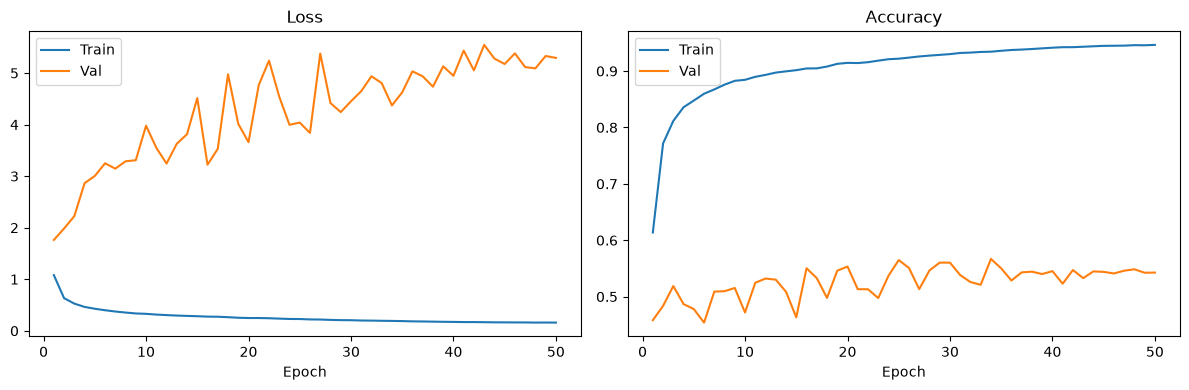

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, EPOCHS+1)

axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs_range, history['train_acc'], label='Train')
axes[1].plot(epochs_range, history['val_acc'],   label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 8 — Final evaluation

Evaluate best CNN on val set + full comparison table.

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def eval_cnn(loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            out = model(X_b.to(device))
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(y_b.numpy())
    return np.array(trues), np.array(preds)

v_true, v_pred = eval_cnn(val_loader)
cnn_acc = accuracy_score(v_true, v_pred)
cnn_f1  = f1_score(v_true, v_pred, average='macro')

print(f'Improved 1D-CNN  val acc: {cnn_acc:.4f}  macro F1: {cnn_f1:.4f}')
results['Improved 1D-CNN'] = {'Accuracy': cnn_acc, 'Macro F1': cnn_f1}

Improved 1D-CNN  val acc: 0.5669  macro F1: 0.5633


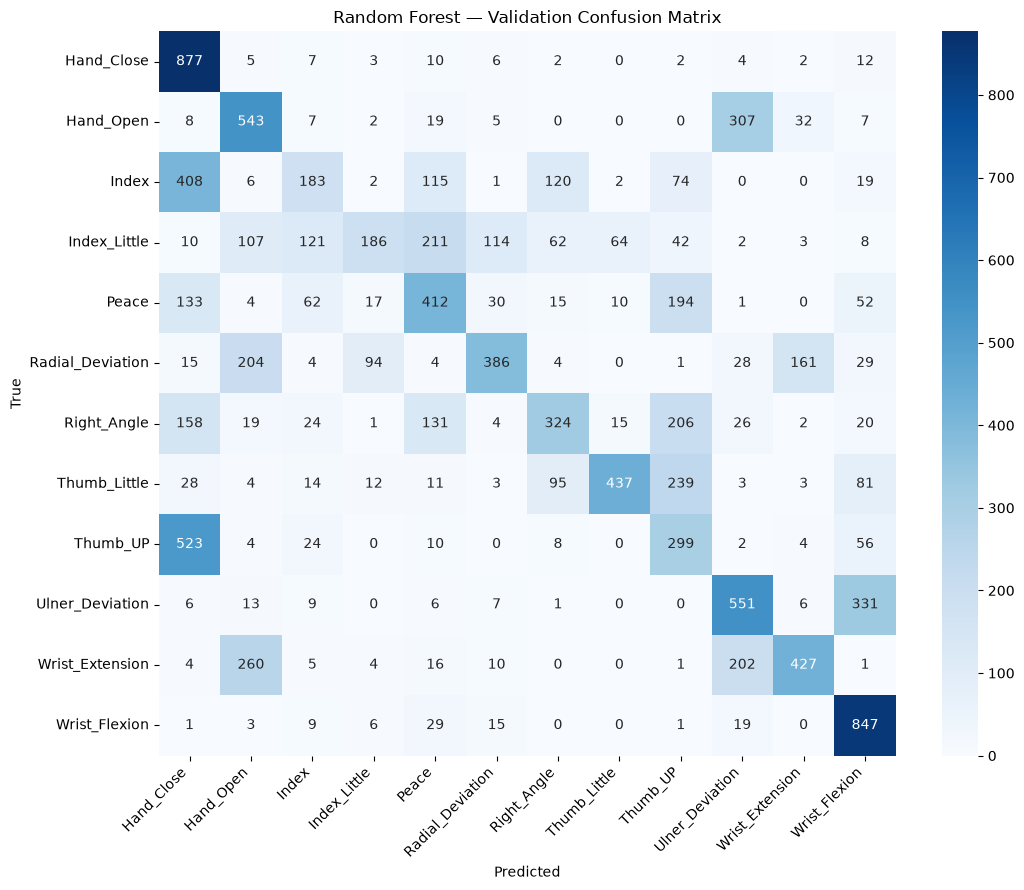

In [21]:
# Confusion matrix for best ML model (RF — paper benchmark)
rf_preds = rf.predict(X_val_s)
cm = confusion_matrix(y_val_enc, rf_preds)

plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest — Validation Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ── Final comparison table ──
baseline_prev = {
    'MLP (prev baseline)':       {'Accuracy': 0.5502, 'Macro F1': 0.5457},
    '1D-CNN (prev baseline)':    {'Accuracy': 0.5241, 'Macro F1': 0.5138},
    'LightGBM (prev baseline)':  {'Accuracy': 0.5193, 'Macro F1': 0.5207},
    'RF (prev baseline)':        {'Accuracy': 0.5145, 'Macro F1': 0.5011},
}

all_results = {**baseline_prev, **results}
df_final = (
    pd.DataFrame(all_results).T
    .sort_values('Accuracy', ascending=False)
)
df_final['Accuracy (%)'] = (df_final['Accuracy'].astype(float) * 100).round(2)
df_final['Macro F1']     = df_final['Macro F1'].astype(float).round(4)
df_final = df_final[['Accuracy (%)', 'Macro F1']]

print('=== Final Baseline Comparison ===')
print(df_final.to_string())
print()
print('Reference (random split, different protocol):')
print('  RF + TSD (Aarotale 2024):  94.95%')
print('  Hybrid model (Çelik 2026, subject-wise): 74.0%')

=== Final Baseline Comparison ===
                          Accuracy (%)  Macro F1
Improved 1D-CNN                  56.69    0.5633
MLP (prev baseline)              55.02    0.5457
1D-CNN (prev baseline)           52.41    0.5138
LightGBM (prev baseline)         51.93    0.5207
RF (prev baseline)               51.45    0.5011
SVM (LinearSVC)                  51.01    0.4937
XGBoost                          50.08    0.4841
Voting Ensemble                  49.83    0.4806
Random Forest                    49.03    0.4735
LightGBM                         48.95    0.4733

Reference (random split, different protocol):
  RF + TSD (Aarotale 2024):  94.95%
  Hybrid model (Çelik 2026, subject-wise): 74.0%
